# 📊  Exploratory Data Analysis (EDA)
## Jumia Nigeria — Home & Kitchen Appliances

In this notebook, we explore the cleaned dataset to uncover patterns, 
trends and insights about the Nigerian home appliance market on Jumia.

### Questions we'll answer:
1. What does the price distribution look like?
2. Which brands list the most products?
3. What is the average price by brand?
4. Which products have the biggest discounts?
5. What is the discount distribution?
6. What are the best value deals on Jumia?

**Input:** `data/cleaned/jumia_kitchen_cleaned.csv`

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Set a clean visual style for all charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Load cleaned data
df = pd.read_csv("../data/cleaned/jumia_kitchen_cleaned.csv")

print(f"✅ Data loaded! {df.shape[0]} products ready for analysis")
df.head()

✅ Data loaded! 183 products ready for analysis


,name,link,page,price,old_price,discount_pct,rating,reviews,discount_amount,discount_pct_calc,value_score
0,Hisense WSPA503 WM 5kg Twin Tub Machine,https://www.jumia.com.ng/hisense-wspa503-wm-5k...,1,170000.0,NaN,32.0,0.0,0.0,NaN,NaN,1.8824
1,3 Litres Whistling Gas & Stove Kettle,https://www.jumia.com.ng/3-litres-whistling-ga...,1,12000.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
2,Hisense 5kg Manual Washing Machine Twin Tub Wi...,https://www.jumia.com.ng/hisense-5kg-manual-wa...,1,162315.0,NaN,26.0,0.0,0.0,NaN,NaN,1.6018
3,Binatone 3 Litres Electric Jug (CEJ-3000) - Bl...,https://www.jumia.com.ng/binatone-3-litres-ele...,1,31919.0,NaN,36.0,0.0,0.0,NaN,NaN,11.2785
4,Legacy 8L Yampounder And Multifunctional Food ...,https://www.jumia.com.ng/8l-yampounder-and-mul...,1,46500.0,NaN,15.0,0.0,0.0,NaN,NaN,3.2258


In [4]:
# Convert price to numeric ( this are issues from the csv file, we have to do the conversion here, or else it erros)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# discount_pct still has "%" sign — remove it first then convert ( annother issue that needed to be fixed)
df["discount_pct"] = (
    df["discount_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)
df["discount_pct"] = pd.to_numeric(df["discount_pct"], errors="coerce")

# Convert old_price and other numeric columns
df["old_price"] = pd.to_numeric(df["old_price"], errors="coerce")
df["discount_amount"] = pd.to_numeric(df["discount_amount"], errors="coerce")
df["discount_pct_calc"] = pd.to_numeric(df["discount_pct_calc"], errors="coerce")

print("✅ Columns converted to numeric!")

print("💰 PRICE SUMMARY (₦)")
print(f"  Cheapest product : ₦{df['price'].min():,.2f}")
print(f"  Most expensive   : ₦{df['price'].max():,.2f}")
print(f"  Average price    : ₦{df['price'].mean():,.2f}")
print(f"  Median price     : ₦{df['price'].median():,.2f}")

print(f"\n🏷️  DISCOUNT SUMMARY")
print(f"  Products with discount : {df['discount_pct'].notna().sum()}")
print(f"  Average discount       : {df['discount_pct'].mean():.1f}%")
print(f"  Highest discount       : {df['discount_pct'].max():.1f}%")

print(f"\n📦 TOTAL PRODUCTS: {len(df)}")

✅ Columns converted to numeric!
💰 PRICE SUMMARY (₦)
  Cheapest product : ₦2,185.00
  Most expensive   : ₦468,500.00
  Average price    : ₦45,369.88
  Median price     : ₦25,999.00

🏷️  DISCOUNT SUMMARY
  Products with discount : 14
  Average discount       : 26.4%
  Highest discount       : 43.0%

📦 TOTAL PRODUCTS: 183


In [5]:
# Extract the first word of the product name as the brand
df["brand"] = df["name"].str.split().str[0]

# Check the top brands
print("🏭 Top 15 Brands by product count:")
print(df["brand"].value_counts().head(15))

🏭 Top 15 Brands by product count:
brand
Binatone    3
SILVER      3
Hisense     2
3           1
Legacy      1
Qasa        1
AKAI        1
ActiveO     1
Century     1
Blender     1
Name: count, dtype: int64


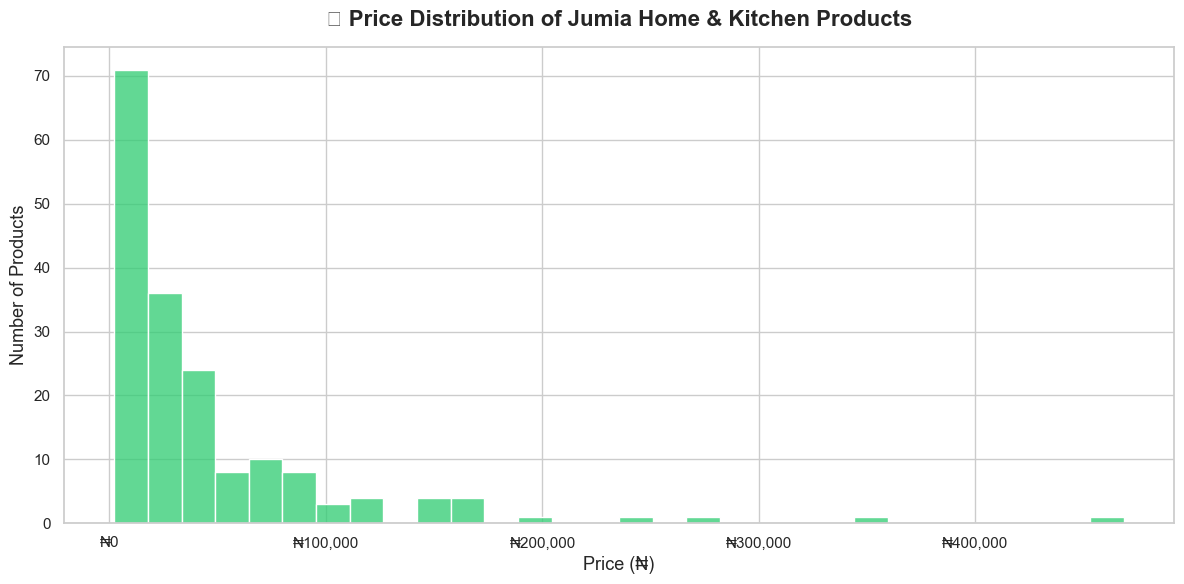

💾 Chart saved!


In [6]:
plt.figure(figsize=(12, 6))

sns.histplot(df["price"], bins=30, color="#2ecc71", edgecolor="white")

plt.title("💰 Price Distribution of Jumia Home & Kitchen Products", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Price (₦)", fontsize=13)
plt.ylabel("Number of Products", fontsize=13)

# Format x-axis to show prices nicely
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₦{x:,.0f}")
)

plt.tight_layout()
plt.savefig("../visuals/01_price_distribution.png", dpi=150)
plt.show()
print("💾 Chart saved!")

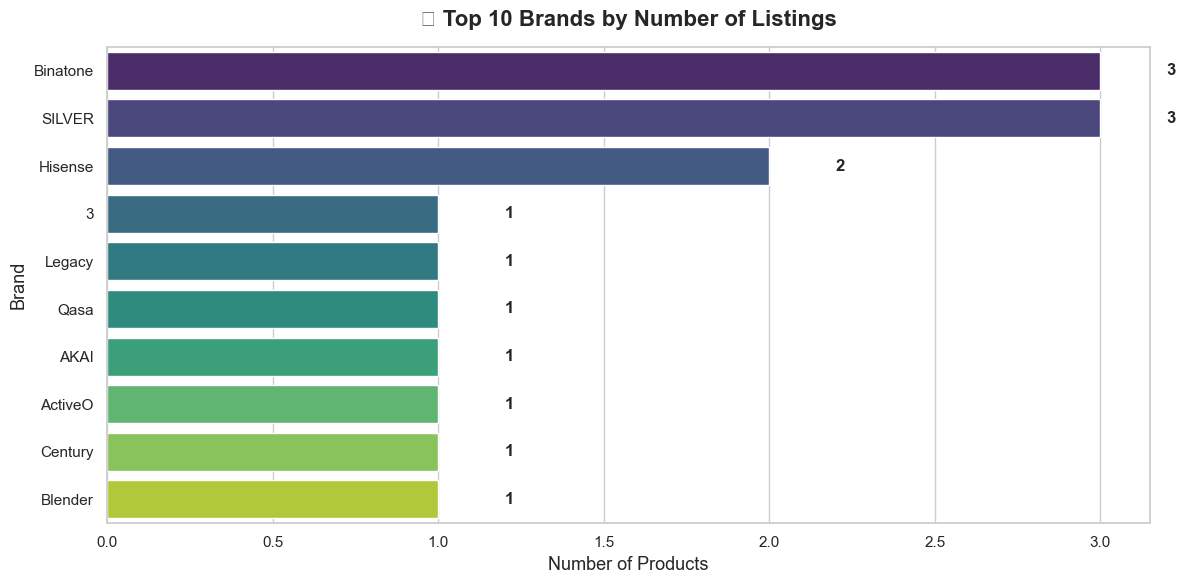

💾 Chart saved!


In [7]:
top_brands = df["brand"].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")

plt.title("🏭 Top 10 Brands by Number of Listings", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Number of Products", fontsize=13)
plt.ylabel("Brand", fontsize=13)

# Add value labels on bars
for i, v in enumerate(top_brands.values):
    plt.text(v + 0.2, i, str(v), va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../visuals/02_top_brands.png", dpi=150)
plt.show()
print("💾 Chart saved!")

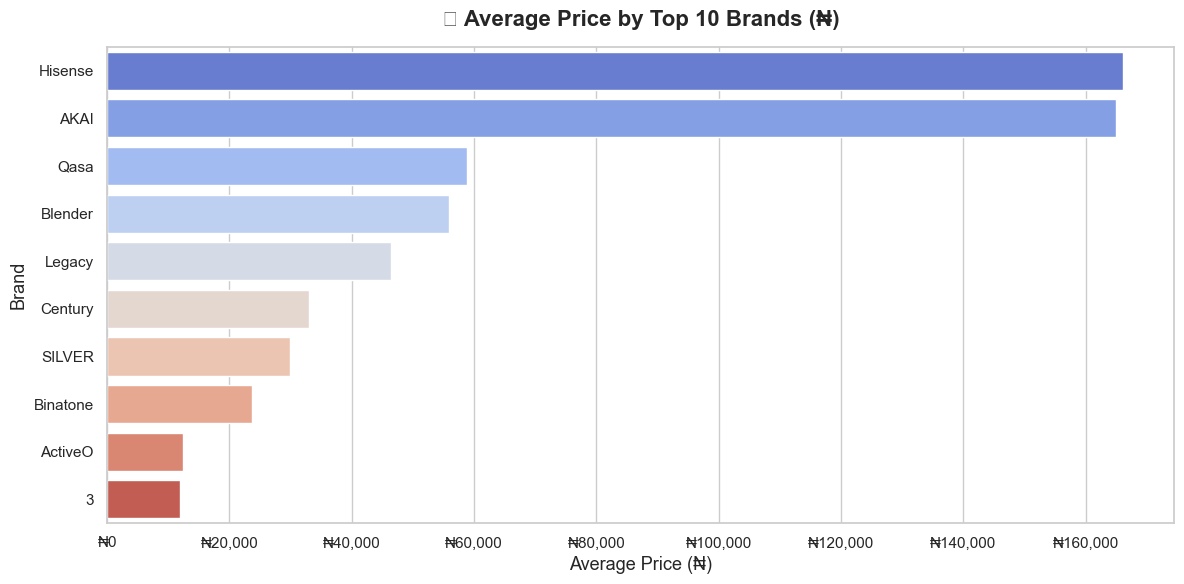

💾 Chart saved!


In [8]:
avg_price = (
    df.groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price.values, y=avg_price.index, palette="coolwarm")

plt.title("💸 Average Price by Top 10 Brands (₦)", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Average Price (₦)", fontsize=13)
plt.ylabel("Brand", fontsize=13)

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₦{x:,.0f}")
)

plt.tight_layout()
plt.savefig("../visuals/03_avg_price_by_brand.png", dpi=150)
plt.show()
print("💾 Chart saved!")

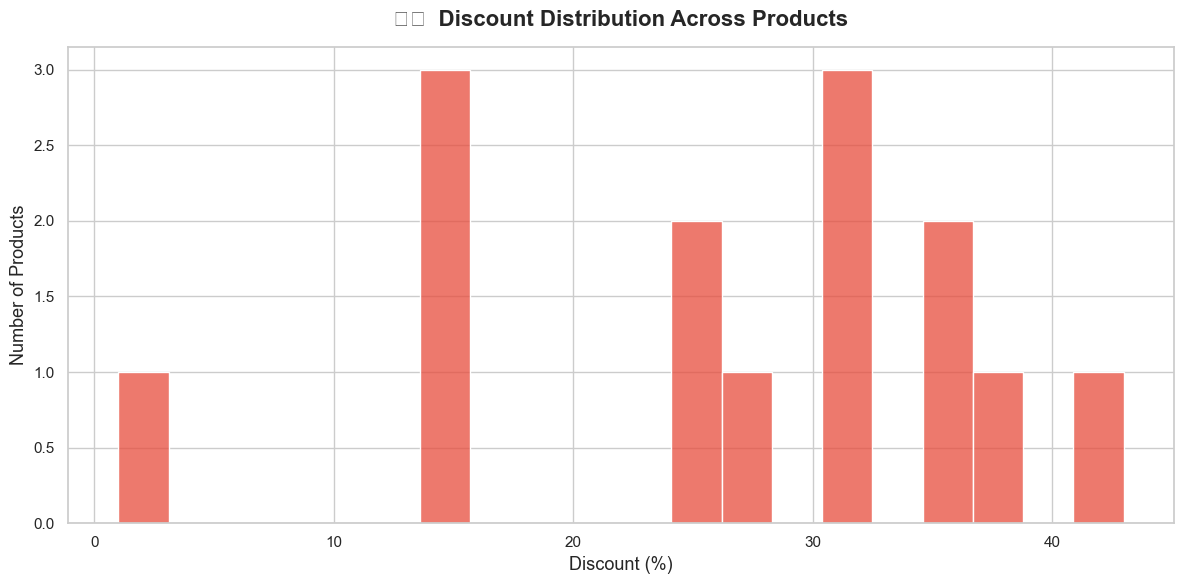

💾 Chart saved!


In [9]:
disc_data = df["discount_pct"].dropna()

plt.figure(figsize=(12, 6))
sns.histplot(disc_data, bins=20, color="#e74c3c", edgecolor="white")

plt.title("🏷️  Discount Distribution Across Products", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Discount (%)", fontsize=13)
plt.ylabel("Number of Products", fontsize=13)

plt.tight_layout()
plt.savefig("../visuals/04_discount_distribution.png", dpi=150)
plt.show()
print("💾 Chart saved!")

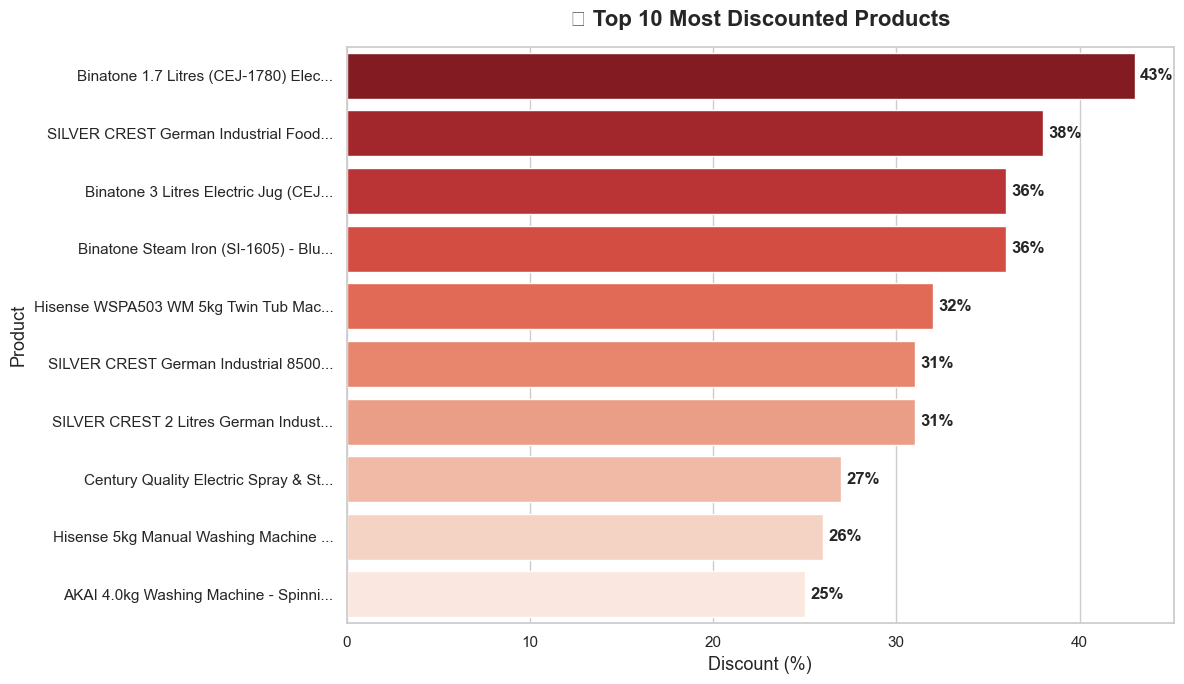

💾 Chart saved!


In [10]:
top_discounts = df[["name", "price", "discount_pct"]].dropna(subset=["discount_pct"])
top_discounts = top_discounts.sort_values("discount_pct", ascending=False).head(10)

# Shorten long names for display
top_discounts["short_name"] = top_discounts["name"].str[:35] + "..."

plt.figure(figsize=(12, 7))
sns.barplot(x="discount_pct", y="short_name", data=top_discounts, palette="Reds_r")

plt.title("🔥 Top 10 Most Discounted Products", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Discount (%)", fontsize=13)
plt.ylabel("Product", fontsize=13)

for i, v in enumerate(top_discounts["discount_pct"].values):
    plt.text(v + 0.3, i, f"{v:.0f}%", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../visuals/05_top_discounts.png", dpi=150)
plt.show()
print("💾 Chart saved!")

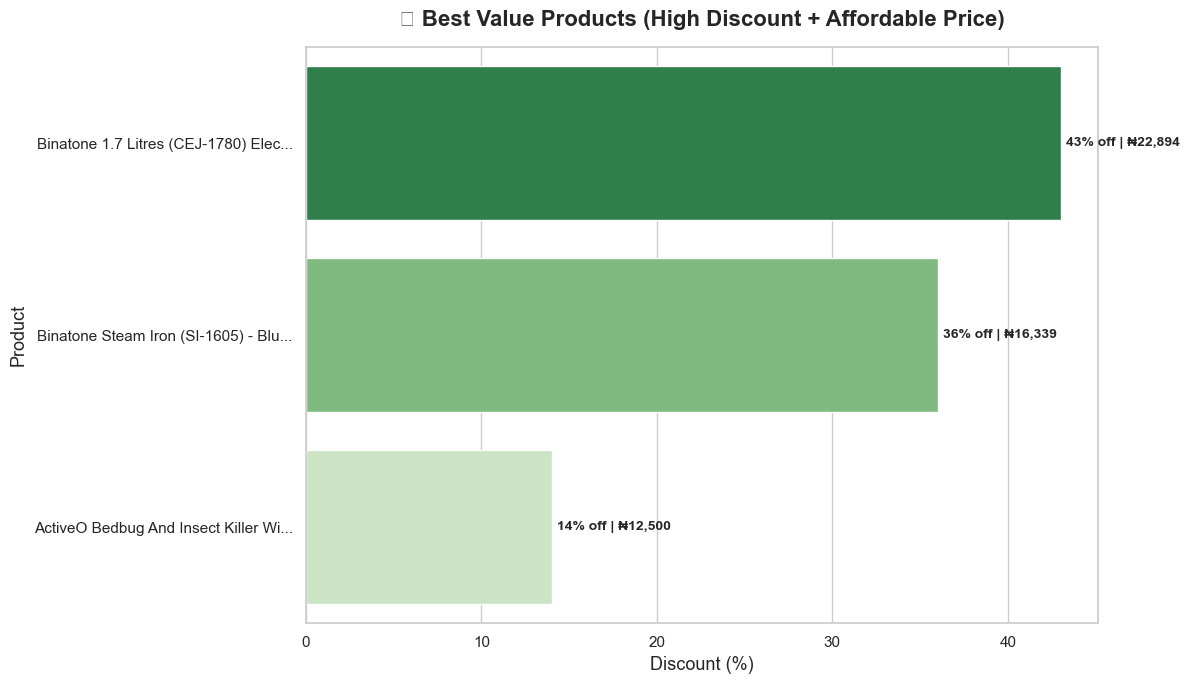

💾 Chart saved!


In [11]:
# Best value = highest discount % at the lowest price
best_value = df[["name", "price", "discount_pct"]].dropna(subset=["discount_pct"])
best_value = best_value[best_value["price"] <= df["price"].quantile(0.5)]  # Bottom 50% price range
best_value = best_value.sort_values("discount_pct", ascending=False).head(10)
best_value["short_name"] = best_value["name"].str[:35] + "..."

plt.figure(figsize=(12, 7))
bars = sns.barplot(x="discount_pct", y="short_name", data=best_value, palette="Greens_r")

plt.title("⭐ Best Value Products (High Discount + Affordable Price)", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Discount (%)", fontsize=13)
plt.ylabel("Product", fontsize=13)

for i, row in enumerate(best_value.itertuples()):
    plt.text(row.discount_pct + 0.3, i, 
             f"{row.discount_pct:.0f}% off | ₦{row.price:,.0f}", 
             va="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig("../visuals/06_best_value.png", dpi=150)
plt.show()
print("💾 Chart saved!")

In [12]:
print("=" * 55)
print("       📊 KEY INSIGHTS — JUMIA HOME & KITCHEN")
print("=" * 55)

print(f"""
📦 Total Products Analysed  : {len(df)}
💰 Price Range              : ₦{df['price'].min():,.0f} — ₦{df['price'].max():,.0f}
📉 Average Price            : ₦{df['price'].mean():,.0f}
🏷️  Products on Discount     : {df['discount_pct'].notna().sum()} ({df['discount_pct'].notna().sum()/len(df)*100:.1f}%)
🔥 Highest Discount         : {df['discount_pct'].max():.0f}%
📊 Average Discount         : {df['discount_pct'].mean():.1f}%
🏆 Most Listed Brand        : {df['brand'].value_counts().index[0]} ({df['brand'].value_counts().iloc[0]} products)
💸 Most Expensive Brand     : {df.groupby('brand')['price'].mean().idxmax()}
""")
print("=" * 55)
print("🎉 Phase 4 Complete! Move on to Phase 5 — Dashboard!")

       📊 KEY INSIGHTS — JUMIA HOME & KITCHEN

📦 Total Products Analysed  : 183
💰 Price Range              : ₦2,185 — ₦468,500
📉 Average Price            : ₦45,370
🏷️  Products on Discount     : 14 (7.7%)
🔥 Highest Discount         : 43%
📊 Average Discount         : 26.4%
🏆 Most Listed Brand        : Binatone (3 products)
💸 Most Expensive Brand     : Hisense

🎉 Phase 4 Complete! Move on to Phase 5 — Dashboard!


In [13]:
# Extract brand from product name and save updated CSV
df["brand"] = df["name"].str.split().str[0]

# Save updated CSV with brand column included
df.to_csv("../data/cleaned/jumia_kitchen_cleaned.csv", index=False)

print("✅ Brand column added and CSV saved!")
print(f"Sample brands: {df['brand'].unique()[:10]}")

✅ Brand column added and CSV saved!
Sample brands: ['Hisense' '3' 'Binatone' 'Legacy' 'Qasa' 'AKAI' 'ActiveO' 'SILVER'
 'Century' 'Blender']


In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned/jumia_kitchen_cleaned.csv")

# List of words that are NOT real brands
not_brands = ["3", "2", "1", "4", "5", "Blender", "Generic", "New", "Mini", "Large"]

# Extract brand - handle NaN values
def extract_brand(name):
    if not isinstance(name, str):  # ← handles NaN and float values
        return "Other"
    words = name.split()
    for word in words:
        if word not in not_brands:
            return word
    return "Other"

df["brand"] = df["name"].apply(extract_brand)

# Verify
print("✅ Brands fixed!")
print(df["brand"].value_counts().head(15))

# Save back to CSV and Excel
df.to_csv("../data/cleaned/jumia_kitchen_cleaned.csv", index=False)
df.to_excel("../data/cleaned/jumia_kitchen_cleaned.xlsx", index=False)

print("\n💾 Both files saved!")

✅ Brands fixed!
brand
Other       168
Binatone      3
SILVER        3
Hisense       2
Litres        1
Legacy        1
Qasa          1
AKAI          1
ActiveO       1
Century       1
+             1
Name: count, dtype: int64

💾 Both files saved!


In [22]:
import pandas as pd

df = pd.read_csv("../data/cleaned/jumia_kitchen_cleaned.csv")

# Much bigger list of words that are NOT brands
not_brands = [
    "3", "2", "1", "4", "5", "6", "7", "8", "9", "10",
    "Blender", "Generic", "New", "Mini", "Large", "Small",
    "Litres", "Litre", "Liter", "Liters", "KG", "Kg", "kg",
    "Electric", "Digital", "Automatic", "Manual", "Multi",
    "Hot", "Cold", "Double", "Single", "Triple", "High",
    "Low", "Ultra", "Super", "Pro", "Plus", "Max", "Air",
    "+", "-", "&", "HD", "LED", "LCD"
]

def extract_brand(name):
    if not isinstance(name, str):
        return "Unknown"
    words = name.split()
    for word in words:
        if word not in not_brands:
            return word
    return "Unknown"

df["brand"] = df["name"].apply(extract_brand)

print("✅ Brands fixed!")
print(df["brand"].value_counts().head(20))

df.to_excel("../data/cleaned/jumia_final.xlsx", index=False)
print("\n💾 Saved!")

✅ Brands fixed!
brand
Unknown      168
Binatone       3
SILVER         3
Hisense        2
Whistling      1
Legacy         1
Qasa           1
AKAI           1
ActiveO        1
Century        1
Cooker         1
Name: count, dtype: int64

💾 Saved!


In [23]:
# Let's see what the actual product names look like
print("Sample product names:")
print(df["name"].head(20).tolist())

print(f"\nTotal NaN names: {df['name'].isna().sum()}")
print(f"Total valid names: {df['name'].notna().sum()}")

Sample product names:
['Hisense WSPA503 WM 5kg Twin Tub Machine', '3 Litres Whistling Gas & Stove Kettle', 'Hisense 5kg Manual Washing Machine Twin Tub With Lint Filter', 'Binatone 3 Litres Electric Jug (CEJ-3000) - Black + 2 Years Warranty', 'Legacy 8L Yampounder And Multifunctional Food Machine Cooper Motor', 'Qasa 2 Litres (QBL-8008 Pro) Commercial Blender', 'Binatone 1.7 Litres (CEJ-1780) Electric Kettle - White + 2 Years Warranty', 'Binatone Steam Iron (SI-1605) - Blue + 2 Years Warranty', 'AKAI 4.0kg Washing Machine - Spinning + Draining Function', 'ActiveO Bedbug And Insect Killer With Diatomaceous Earth - 500g', 'SILVER CREST German Industrial Food Crusher Blender, EXTRA MILL JAR', 'Century Quality Electric Spray & Steam Iron.', 'Blender + Electric Cooker + Electric Kettle + Toaster', 'SILVER CREST German Industrial 8500W Food Crusher Blender, EXTRA MILL JAR', 'SILVER CREST 2 Litres German Industrial Blender 8500W', nan, nan, nan, nan, nan]

Total NaN names: 168
Total valid nam

In [24]:
import pandas as pd

df = pd.read_csv("../data/cleaned/jumia_kitchen_cleaned.csv")

# Create price range buckets
bins = [0, 10000, 25000, 50000, 100000, 200000, 500000]
labels = ["₦0-10k", "₦10k-25k", "₦25k-50k", "₦50k-100k", "₦100k-200k", "₦200k+"]

df["price_range"] = pd.cut(df["price"], bins=bins, labels=labels)

print("✅ Price ranges created!")
print(df["price_range"].value_counts().sort_index())

# Save
df.to_csv("../data/cleaned/jumia_kitchen_cleaned.csv", index=False)
df.to_excel("../data/cleaned/jumia_final.xlsx", 
            sheet_name="jumia_kitchen_cleaned",
            index=False)
print("\n💾 Saved!")

✅ Price ranges created!
price_range
₦0-10k        41
₦10k-25k      60
₦25k-50k      51
₦50k-100k     35
₦100k-200k    13
₦200k+         4
Name: count, dtype: int64

💾 Saved!


In [25]:
# Create discount range buckets
bins = [0, 10, 20, 30, 40, 50]
labels = ["1-10%", "11-20%", "21-30%", "31-40%", "41-50%"]

df["discount_range"] = pd.cut(df["discount_pct"], bins=bins, labels=labels)

print("✅ Discount ranges created!")
print(df["discount_range"].value_counts().sort_index())

# Save
df.to_csv("../data/cleaned/jumia_kitchen_cleaned.csv", index=False)
df.to_excel("../data/cleaned/jumia_final.xlsx",
            sheet_name="jumia_kitchen_cleaned",
            index=False)
print("\n💾 Saved!")

✅ Discount ranges created!
discount_range
1-10%     1
11-20%    3
21-30%    3
31-40%    6
41-50%    1
Name: count, dtype: int64

💾 Saved!
